In [ ]:
import numpy as np

# Define new column names
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

# Assign new column names to the DataFrame
df.columns = column_names

# Replace '?' with NaN
df = df.replace('?', np.nan)

# Convert all columns to numeric, coercing errors to NaN
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Impute missing values for numerical columns with the mean
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
for col in numerical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

# Impute missing values for categorical columns with the mode
categorical_cols_for_imputation = ['ca', 'thal']
for col in categorical_cols_for_imputation:
    if df[col].isnull().any():
        # Mode might return multiple values, pick the first one
        df[col] = df[col].fillna(df[col].mode()[0])

# Convert 'target' column to binary (0 or 1)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# Identify and convert categorical columns to 'category' dtype
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for col in categorical_features:
    df[col] = df[col].astype('category')

# Perform one-hot encoding on categorical columns
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)

print("Preprocessed DataFrame head:")
print(df.head())
print("\nPreprocessed DataFrame info:")
df.info()

Preprocessed DataFrame head:
    age  trestbps   chol  thalach  oldpeak  target  sex_1.0  cp_2.0  cp_3.0  \
0  63.0     145.0  233.0    150.0      2.3       0     True   False   False   
1  67.0     160.0  286.0    108.0      1.5       1     True   False   False   
2  67.0     120.0  229.0    129.0      2.6       1     True   False   False   
3  37.0     130.0  250.0    187.0      3.5       0     True   False    True   
4  41.0     130.0  204.0    172.0      1.4       0    False    True   False   

   cp_4.0  fbs_1.0  restecg_1.0  restecg_2.0  exang_1.0  slope_2.0  slope_3.0  \
0   False     True        False         True      False      False       True   
1    True    False        False         True       True       True      False   
2    True    False        False         True       True       True      False   
3   False    False        False        False      False      False       True   
4   False    False        False         True      False      False      False   

   ca_1.0

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries 'matplotlib.pyplot' and 'seaborn' imported successfully.")

Libraries 'matplotlib.pyplot' and 'seaborn' imported successfully.


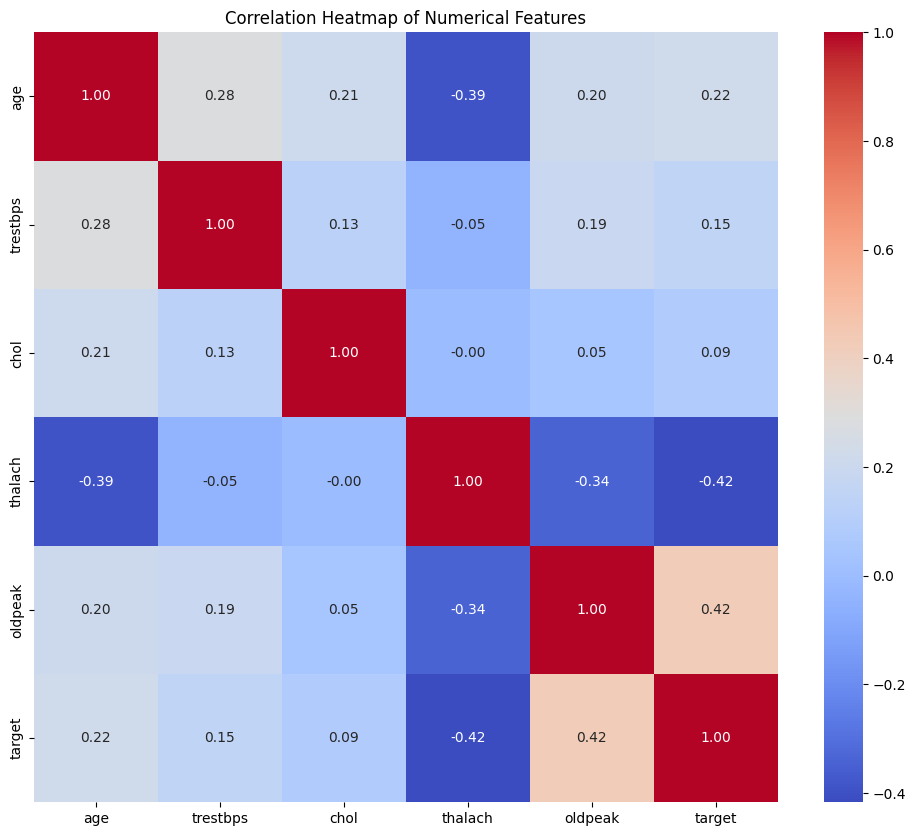

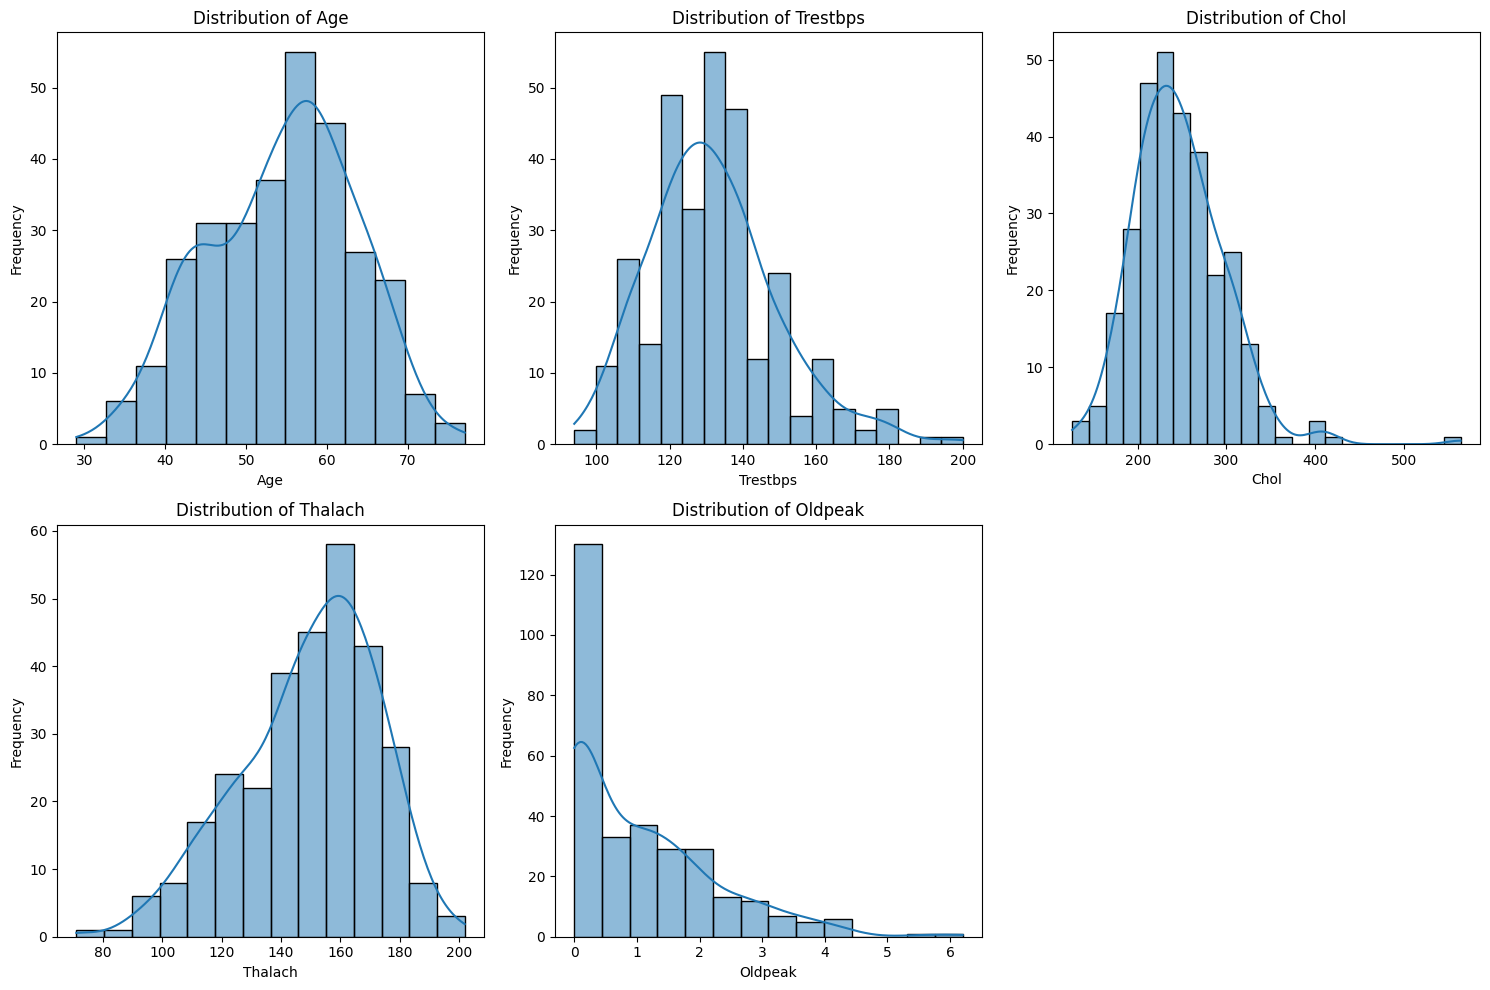

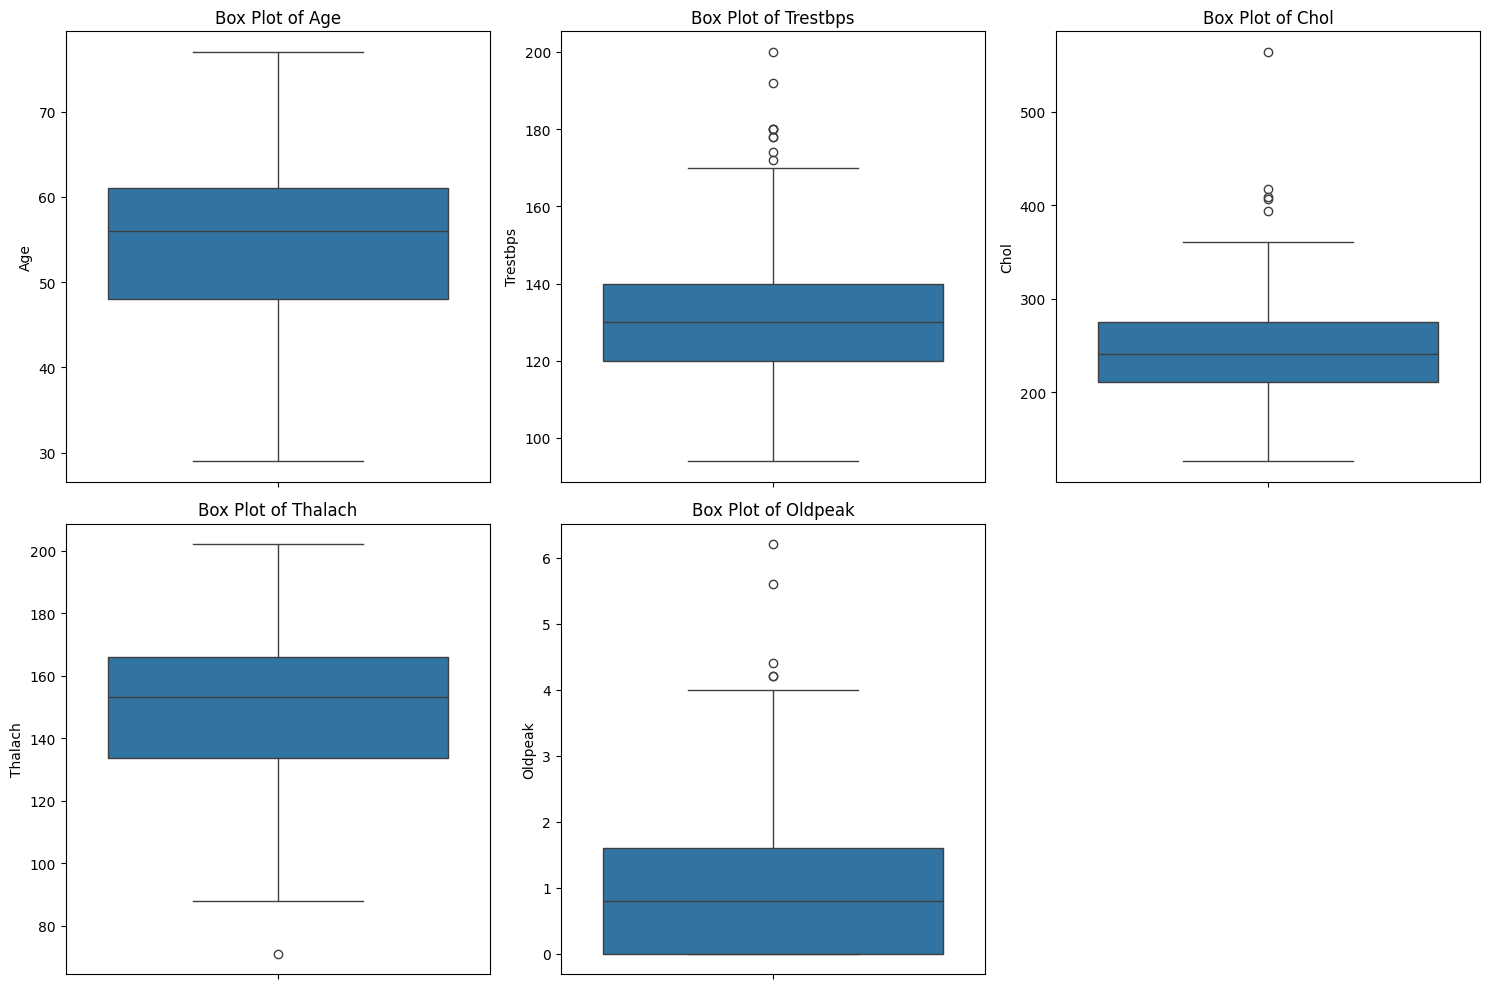

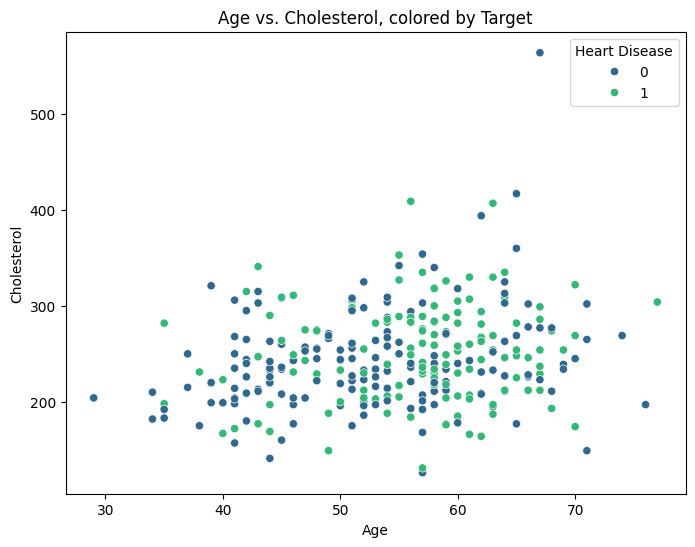

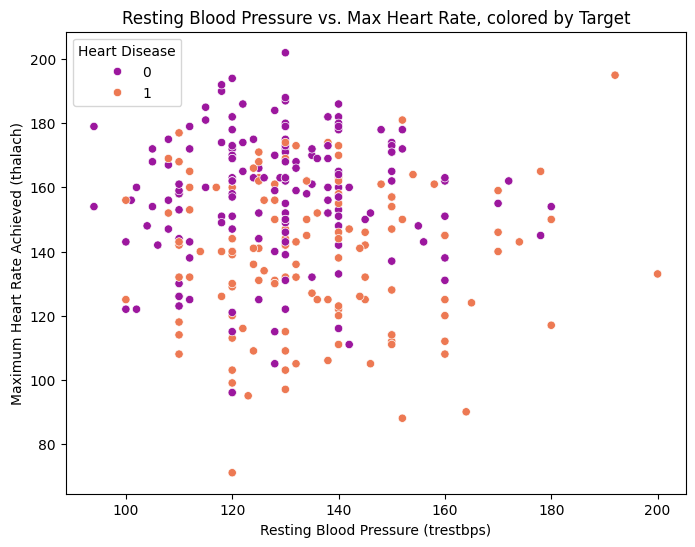

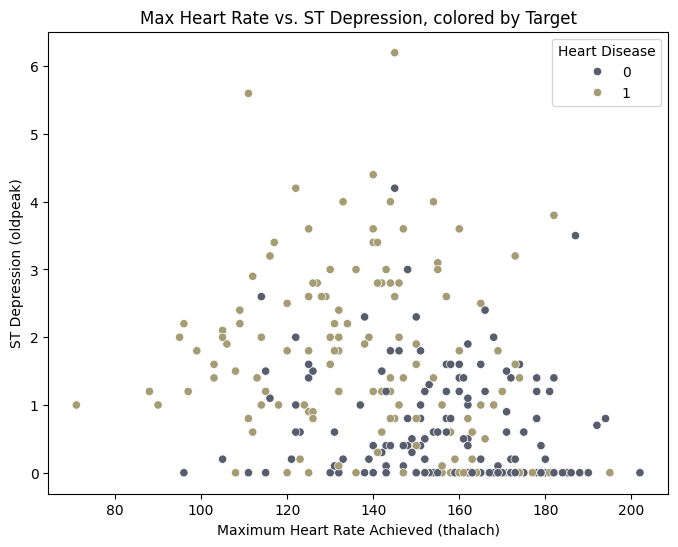

Visualizations generated successfully: correlation heatmap, histograms, box plots, and scatter plots.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Calculate the correlation matrix for numerical features
# Select only numerical features from the DataFrame for correlation calculation
numerical_features_for_corr = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target'] # Include target for correlation as it's numeric now
correlation_matrix = df[numerical_features_for_corr].corr()

# 3. Create a correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# 4. Generate histograms for numerical columns
# Numerical columns are already defined in the previous step: numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Extend numerical_cols to include target if not already there, for completeness in plotting distributions
numerical_cols_hist = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak'] # Already defined in previous steps, reusing

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_hist):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 5. Generate box plots for numerical columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_hist):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col.capitalize()}')
    plt.ylabel(col.capitalize())
plt.tight_layout()
plt.show()

# 6. Create scatter plots for relevant feature pairs
# Choose at least three meaningful pairs, and color by 'target'

# Pair 1: 'age' vs. 'chol'
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='age', y='chol', hue='target', palette='viridis')
plt.title('Age vs. Cholesterol, colored by Target')
plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.legend(title='Heart Disease')
plt.show()

# Pair 2: 'thalach' vs. 'trestbps'
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='trestbps', y='thalach', hue='target', palette='plasma')
plt.title('Resting Blood Pressure vs. Max Heart Rate, colored by Target')
plt.xlabel('Resting Blood Pressure (trestbps)')
plt.ylabel('Maximum Heart Rate Achieved (thalach)')
plt.legend(title='Heart Disease')
plt.show()

# Pair 3: 'oldpeak' vs. 'thalach'
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='thalach', y='oldpeak', hue='target', palette='cividis')
plt.title('Max Heart Rate vs. ST Depression, colored by Target')
plt.xlabel('Maximum Heart Rate Achieved (thalach)')
plt.ylabel('ST Depression (oldpeak)')
plt.legend(title='Heart Disease')
plt.show()

print("Visualizations generated successfully: correlation heatmap, histograms, box plots, and scatter plots.")

In [17]:
from sklearn.preprocessing import MinMaxScaler

# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Identify numerical and one-hot encoded categorical columns for scaling
# Numerical columns are float64
numerical_cols_for_scaling = X.select_dtypes(include=['float64']).columns

# Columns that are not numerical and not the target variable are likely one-hot encoded bools
# We will exclude these from scaling, as they are already in a binary format (0 or 1).
# We explicitly get column names to avoid inadvertently scaling boolean columns that are direct outputs of get_dummies.
bool_cols_for_dummies = X.select_dtypes(include=['bool']).columns

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Apply scaling only to numerical features
X[numerical_cols_for_scaling] = scaler.fit_transform(X[numerical_cols_for_scaling])

# Recombine scaled features with non-scaled features (if any, like original boolean columns)
# In this case, `X` already contains the boolean columns, so no separate recombination is strictly needed
# beyond ensuring they were not scaled.

# Display the head of the normalized DataFrame and its info to confirm changes
df_normalized = pd.concat([X, y], axis=1)

print("Normalized DataFrame head:")
print(df_normalized.head())
print("\nNormalized DataFrame info:")
df_normalized.info()


Normalized DataFrame head:
        age  trestbps      chol   thalach   oldpeak  sex_1.0  cp_2.0  cp_3.0  \
0  0.708333  0.481132  0.244292  0.603053  0.370968     True   False   False   
1  0.791667  0.622642  0.365297  0.282443  0.241935     True   False   False   
2  0.791667  0.245283  0.235160  0.442748  0.419355     True   False   False   
3  0.166667  0.339623  0.283105  0.885496  0.564516     True   False    True   
4  0.250000  0.339623  0.178082  0.770992  0.225806    False    True   False   

   cp_4.0  fbs_1.0  restecg_1.0  restecg_2.0  exang_1.0  slope_2.0  slope_3.0  \
0   False     True        False         True      False      False       True   
1    True    False        False         True       True       True      False   
2    True    False        False         True       True       True      False   
3   False    False        False        False      False      False       True   
4   False    False        False         True      False      False      False   

   ca